# Alpha geodesics on the space of Univariate Normal Distributions

> Objective: vizualise the geodesics induced by the alpha connexions on the space of univariate normal distributions, and compare with the Fisher geodesic. 

In [5]:
import matplotlib.pyplot as plt

import geomstats.backend as gs
import geomstats.visualization as visualization
from geomstats.integrator import integrate
from geomstats.information_geometry.normal import UnivariateNormalDistributions, UnivariateNormalAlpha

## Computation of geodesics

We first try to use the method connection.geodesic and if it doesn't work, we integrate the geodesic equation. 

In [17]:
def alpha_curve(space, alpha, start_point, initial_tangent_vec, n_steps=200, end_time=5.0):
    connection = UnivariateNormalAlpha(space=space, alpha=alpha)

    times = gs.linspace(0.0, end_time, n_steps)

    if hasattr(connection, "exp_solver"):
        geodesic = connection.geodesic(
            initial_point=start_point,
            initial_tangent_vec=initial_tangent_vec,
        )
        points = geodesic(times)
    else:
        initial_state = gs.stack([start_point, initial_tangent_vec], axis=0)
        flow = integrate(
            function=lambda state, t: connection.geodesic_equation(state),
            initial_state=initial_state,
            end_time=end_time,
            n_steps=n_steps,
            step="rk4",
        )
        states = gs.stack(flow, axis=0)
        points = states[:, 0, :]
    points = points[points[:, 1] > 1e-6]
    return points


def fisher_curve(space, start_point, initial_tangent_vec, n_steps=20, end_time=5.0):
    geodesic = space.metric.geodesic(
        initial_point=start_point,
        initial_tangent_vec=initial_tangent_vec,
    )
    times = gs.linspace(0.0, end_time, n_steps)
    points = geodesic(times)
    points = points[points[:, 1] > 1e-6]
    return points

## Vizualisation

For some exemples of alphas (-1,-0.5,0,0.5,1)

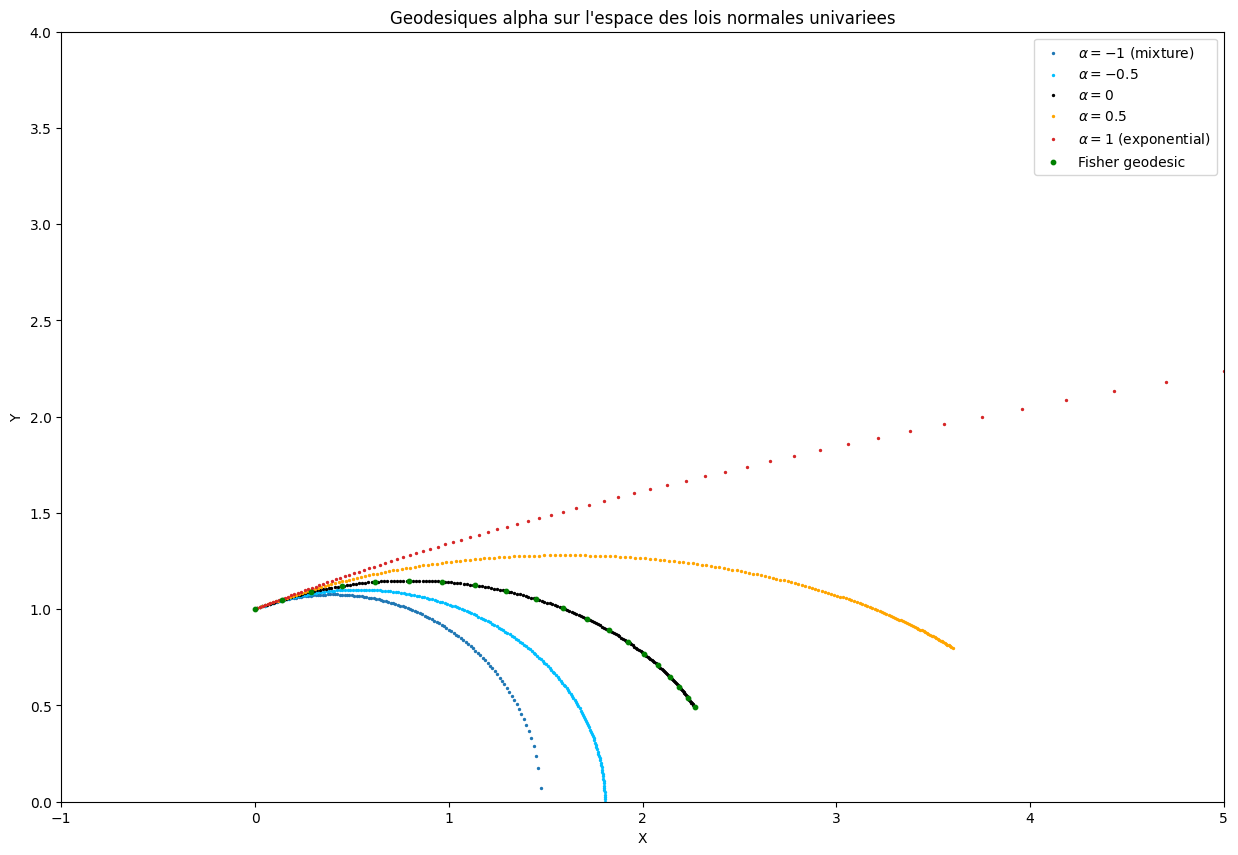

In [18]:
space = UnivariateNormalDistributions()
start_point = gs.array([0.0, 1.0])
initial_tangent_vec = gs.array([0.5, 0.2])

alphas = [-1.0, -0.5, 0.0, 0.5, 1.0]
colors = ["tab:blue", "deepskyblue", "black", "orange", "tab:red"]
labels = [
    r"$\alpha=-1$ (mixture)",
    r"$\alpha=-0.5$",
    r"$\alpha=0$",
    r"$\alpha=0.5$",
    r"$\alpha=1$ (exponential)",
]

fig, ax = plt.subplots(figsize=(15, 10))
ax.set_xlim(-1, 5)
ax.set_ylim(0, 4)

for alpha, color, label in zip(alphas, colors, labels):
    points = alpha_curve(space, alpha, start_point, initial_tangent_vec)
    visualization.plot(
        points,
        ax=ax,
        space="H2_poincare_half_plane",
        coords_type="half-space",
        marker=".",
        color=color,
        s=8,
        label=label,
    )

fisher_points = fisher_curve(space, start_point, initial_tangent_vec)
visualization.plot(
    fisher_points,
    ax=ax,
    space="H2_poincare_half_plane",
    coords_type="half-space",
    marker="o",
    color="green",
    s=10,
    label="Fisher geodesic",
)

ax.legend(loc="best")
ax.set_title("Geodesiques alpha sur l'espace des lois normales univariees")
plt.show()